# 01 — Score a tournament from scratch

The full pipeline on the 2022 FIFA World Cup (StatsBomb open data): load events, compute every measure, standardize against the group stage, and publish the 0-10 board.

The weights were selected on 2026 data only. On the 2022 data, the index rates the Argentina-France final 9.59 and ranks it first of 64 matches.

## How the rating is built

The index turns one soccer match into a single 0-10 number in four steps. Every cell below carries out one of them.

1. **Measure.** For each match, about 57 numbers are computed from the raw event feed — shots, expected goals, win-probability swings, cards, saves, tempo, and so on. These are the *measures*.
2. **Standardize.** Each measure is turned into a z-score against a reference pool of matches (here, the group stage): how many standard deviations above or below the typical match this one sits. Standardizing lets measures on different scales be added together.
3. **Aggregate into five buckets.** The standardized measures are grouped and weighted into five display buckets — **stakes, chances, drama, spectacle, payoff**. Their weighted sum is the *raw score*. Two optional deductions (a dead-rubber tax and a knockout-aliveness tax) fold into the stakes bucket.
4. **Scale to 0-10.** The raw scores are mapped onto a 0-10 display scale fitted on the reference pool, producing the *rating*.

The weights were fixed on 2026 data and are not tuned here — the 2022 tournament is scored with those frozen settings, which is why this notebook is a clean out-of-sample check.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("../src"))
os.environ.setdefault("EXCITEMENT_INDEX_CACHE", os.path.abspath("../.opendata_cache"))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.width", 140)

The cell above is environment setup, not analysis. It puts the local `src/` directory on the import path so `import excitement_index` resolves to this repo, and it points `EXCITEMENT_INDEX_CACHE` at a folder where downloaded StatsBomb open data is stored so it is fetched only once. The warning filter and pandas display width are cosmetic.

## Load matches and build the feature matrix

About 57 measures per match. The first run downloads and caches event data (roughly 5 minutes); subsequent runs read the cache.

In [2]:
from pathlib import Path
from excitement_index import opendata, build_feature_matrix

CACHE = Path("wc2022_features.parquet")
matches = opendata.load_matches("FIFA World Cup", "2022")
if CACHE.exists():
    features = pd.read_parquet(CACHE)
else:
    features = build_feature_matrix(matches, opendata.load_events,
                                    elo=opendata.load_elo(), jeopardy=False)
    features.to_parquet(CACHE)
print(features.shape)

(64, 64)


### Reading the output

`build_feature_matrix` returns one row per match and one column per measure (plus a few metadata columns such as `home`, `away`, `stage`, and the `knockout` flag). The printed shape `(64, 64)` is therefore 64 matches by 64 columns. It is indexed by StatsBomb `match_id`.

The first run downloads and parses every match's events, which is slow; the result is written to `wc2022_features.parquet` and every later run reads that file instead. Nothing here is scored yet — these are the raw per-match measures that feed the next step. You can inspect them directly, e.g. `features[["total_npxg", "total_shots", "gei"]].head()`.

## Score

The reference pool is the tournament's group stage: every measure is standardized against those 48 matches.

In [3]:
from excitement_index import score_matches

group_ids = features.index[features["knockout"] == 0]
board = score_matches(features, reference_ids=list(group_ids))
board["rank"] = range(1, len(board) + 1)
board[["rank", "home", "away", "stage", "rating"]].head(15)

,rank,home,away,stage,rating
match_id,,,,,
3869685,1,Argentina,France,final,9.59
3869420,2,Croatia,Brazil,quarter-finals,9.49
3857292,3,Costa Rica,Germany,group,9.46
3869321,4,Netherlands,Argentina,quarter-finals,9.37
3869354,5,England,France,quarter-finals,9.32
3857284,6,Germany,Japan,group,9.26
3857259,7,Cameroon,Serbia,group,9.08
3869219,8,Japan,Croatia,round of 16,9.06
3857256,9,Serbia,Switzerland,group,8.84


### Reading the board

`score_matches` runs steps 2–4 from the overview. `reference_ids` names the matches used as the standardization pool — here the 48 group-stage games (`knockout == 0`). Every measure's mean and standard deviation are taken over that pool, so a `rating` answers "how exciting was this match relative to a typical group game?"

The returned board is sorted best-first. `rating` is the 0-10 display value; the `rank` column added above is just its 1-based position. Using the group stage as the yardstick is a deliberate choice: it is the largest, most homogeneous block of matches in the tournament, which makes the standardization stable. The knockout matches are then scored against that same yardstick.

The two figures below give a feel for the board as a whole: first where the 64 ratings fall, then how the rating tracks two of the underlying measures.

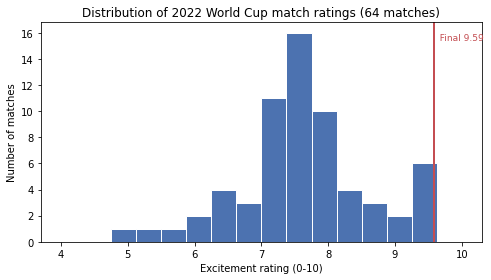

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(board["rating"], bins=16, range=(4, 10), color="#4C72B0", edgecolor="white")
final_rating = board.loc[3869685, "rating"]
ax.axvline(final_rating, color="#C44E52", lw=2)
ax.text(final_rating, ax.get_ylim()[1] * 0.95, f"  Final {final_rating:.2f}",
        color="#C44E52", va="top", ha="left", fontsize=9)
ax.set_xlabel("Excitement rating (0-10)")
ax.set_ylabel("Number of matches")
ax.set_title("Distribution of 2022 World Cup match ratings (64 matches)")
plt.tight_layout()
plt.show()

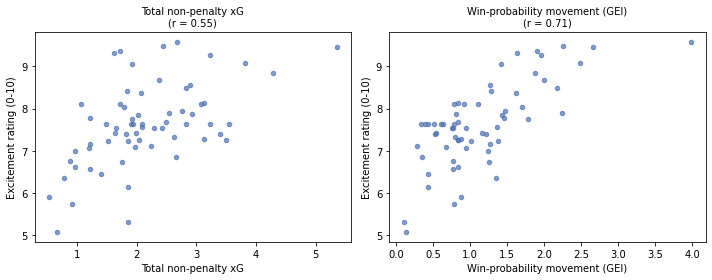

In [5]:
import matplotlib.pyplot as plt

df = board.join(features[["total_npxg", "gei"]])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(
        axes,
        ["total_npxg", "gei"],
        ["Total non-penalty xG", "Win-probability movement (GEI)"]):
    ax.scatter(df[col], df["rating"], s=20, color="#4C72B0", alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel("Excitement rating (0-10)")
    r = df[col].corr(df["rating"])
    ax.set_title(f"{label}\n(r = {r:.2f})", fontsize=10)
plt.tight_layout()
plt.show()

## The final's decomposition

The five bucket values sum to the raw score.

In [6]:
final = board.loc[3869685]   # Argentina vs France
print(f"Argentina 3-3 France (4-2 pens)  ->  {final['rating']:.2f}/10, rank #{int(final['rank'])} of {len(board)}")
final[[c for c in board.columns if c.startswith('bucket_') or c.startswith('tax_')]]

Argentina 3-3 France (4-2 pens)  ->  9.59/10, rank #1 of 64


bucket_stakes       0.404816
bucket_chances      0.214174
bucket_drama        0.210654
bucket_spectacle    0.184956
bucket_payoff       0.324376
tax_dead_rubber         -0.0
tax_aliveness           -0.0
Name: 3869685, dtype: object

### Reading the decomposition

The five `bucket_` values are the standardized, weighted contributions from step 3, and they sum exactly to the match's **raw** score (not to the 0-10 rating, which is the raw score after the display scaling). For this final, *stakes* and *payoff* are the largest contributors — a knockout with a shootout resolution scores high on both.

The two `tax_` line items are the dead-rubber and aliveness deductions, reported as signed values that are already folded into the stakes bucket. Both are `-0.0` here: a World Cup final is neither a dead rubber nor a match that was decided early, so neither penalty applies.

The next two figures look inside this single match: the five bucket contributions as a bar chart, and the live win-probability curve that the drama measures are computed from.

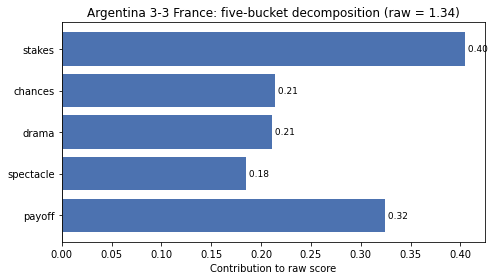

In [7]:
import matplotlib.pyplot as plt

buckets = ["stakes", "chances", "drama", "spectacle", "payoff"]
vals = [float(final[f"bucket_{b}"]) for b in buckets]
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in vals]
ax.barh(buckets, vals, color=colors)
ax.axvline(0, color="0.4", lw=0.8)
for y, v in enumerate(vals):
    ax.text(v, y, f" {v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlabel("Contribution to raw score")
ax.set_title(f"Argentina 3-3 France: five-bucket decomposition (raw = {final['raw']:.2f})")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

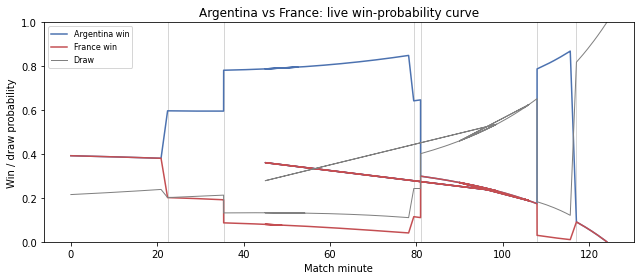

In [8]:
import matplotlib.pyplot as plt
from excitement_index import wp, resolve_team_name, playable_events

ev = opendata.load_events(3869685)
teams = set(playable_events(ev)["team"].dropna().unique())
h = resolve_team_name(final["home"], teams)
a = resolve_team_name(final["away"], teams)
curve = wp.wp_curve(ev, home=h, away=a)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curve["_t"], curve["p_home"], color="#4C72B0", label=f"{h} win")
ax.plot(curve["_t"], curve["p_away"], color="#C44E52", label=f"{a} win")
ax.plot(curve["_t"], curve["p_draw"], color="0.5", lw=1, label="Draw")
goals = curve[curve["d"].diff().fillna(0) != 0]
for t in goals["_t"]:
    ax.axvline(t, color="0.8", lw=0.8, zorder=0)
ax.set_xlabel("Match minute")
ax.set_ylabel("Win / draw probability")
ax.set_ylim(0, 1)
ax.set_title(f"{h} vs {a}: live win-probability curve")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## The bottom of the board

In [9]:
board[["rank", "home", "away", "rating"]].tail(5)

,rank,home,away,rating
match_id,,,,
3857301,60,Qatar,Senegal,6.14
3857289,61,Argentina,Mexico,5.91
3857287,62,Uruguay,South Korea,5.74
3857294,63,Netherlands,Qatar,5.32
3857286,64,Qatar,Ecuador,5.07


### Recap

The bottom of the board is dominated by low-event, one-sided group games — the opposite profile to the final. Following one match through the pipeline: its measures live in `features.loc[match_id]`, its standardized bucket contributions and taxes in `board.loc[match_id]`, and the rating is the raw bucket sum after the 0-10 scaling fitted on the group stage.

To experiment, change `reference_ids` to a different pool, or pass a `config=` override to `score_matches` to reweight the buckets, and re-run from the scoring cell.